# EDA, Análisis exploratorio gastos personales


EDA de más de N movimientos bancarios: categorización automática de gastos, análisis mensual por categoría e identificación de patrones de consumo.

## Pregunta de negocio:

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

### Subpreguntas

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?
2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?
3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

### Parte predictiva

1. Dado mi historial de ingresos y gastos por categoría, ¿cuál es mi gasto y ahorro esperados el próximo mes si no cambio nada?
2. ¿Qué efecto tendría reducir un X % el gasto en determinadas categorías sobre mi ahorro esperado?

### Importaciones de librerias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Carga de datos e Información del dataset

In [3]:
datos = "gastos_personales_2024.csv"

In [4]:
from iniciar_dataframe import informacion_df

# Función propia para analizar el dataframe. De forma rápida y sencilla, arroja todos los datos necesarios
df = informacion_df(datos)

▶ Head (5 filas):


,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia
1,2024-01-01,Gasto,Transporte,-31.18,4843.32,Pago con tarjeta,Tarjeta
2,2024-01-02,Gasto,Alimentación,-58.44,4784.89,Pago con tarjeta,Tarjeta
3,2024-01-03,Gasto,Transporte,-8.37,4776.52,Pago con tarjeta,Tarjeta
4,2024-01-03,Gasto,Alimentación,-35.29,4741.23,Pago con tarjeta,Tarjeta



▶ Info del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  582 non-null    str    
 1   tipo_movimiento        582 non-null    str    
 2   categoria              582 non-null    str    
 3   importe_eur            582 non-null    float64
 4   saldo_post_movimiento  582 non-null    float64
 5   descripcion            582 non-null    str    
 6   canal                  582 non-null    str    
dtypes: float64(2), str(5)
memory usage: 32.0 KB

▶ Dimensiones (shape):
(582, 7)

▶ Columnas:
['fecha', 'tipo_movimiento', 'categoria', 'importe_eur', 'saldo_post_movimiento', 'descripcion', 'canal']

▶ Descripción estadística (describe numérico):


,importe_eur,saldo_post_movimiento
count,582.000000,582.000000
mean,-7.873660,-267.471684
std,366.015027,1767.677453
min,-1033.920000,-3159.600000
25%,-50.307500,-1951.422500
50%,-35.770000,-317.070000
75%,-21.582500,1127.265000
max,2442.580000,4874.510000



▶ Tipos de datos:
fecha                        str
tipo_movimiento              str
categoria                    str
importe_eur              float64
saldo_post_movimiento    float64
descripcion                  str
canal                        str
dtype: object


### Limpieza de datos

In [5]:
df.isnull().sum()

fecha                    0
tipo_movimiento          0
categoria                0
importe_eur              0
saldo_post_movimiento    0
descripcion              0
canal                    0
dtype: int64

No se registran datos inválidos

### Transformación de datos

In [6]:
df["fecha"] = pd.to_datetime(df["fecha"])

In [7]:
df["mes"] = df["fecha"].dt.strftime("%B")
df["mes"]

0       January
1       January
2       January
3       January
4       January
         ...   
577    December
578    December
579    December
580    December
581    December
Name: mes, Length: 582, dtype: str

In [8]:
df["dia"] = df["fecha"].dt.strftime("%A")
df["dia"]

0         Monday
1         Monday
2        Tuesday
3      Wednesday
4      Wednesday
         ...    
577       Sunday
578       Sunday
579       Monday
580      Tuesday
581      Tuesday
Name: dia, Length: 582, dtype: str

In [9]:
#redondeamos el saldo post movimiento en 2 decimales por mas comodidad
df["saldo_post_movimiento"] = df["saldo_post_movimiento"].round(2)

In [10]:
#funcion que agrega una columna de alerta, donde si el sueldo esta por debajo de -100, avisa que es saldo negativo
df["alerta"] = df["saldo_post_movimiento"].apply(lambda x: "Saldo negativo" if x < 0 else None)

### Análisis Variantes numéricas

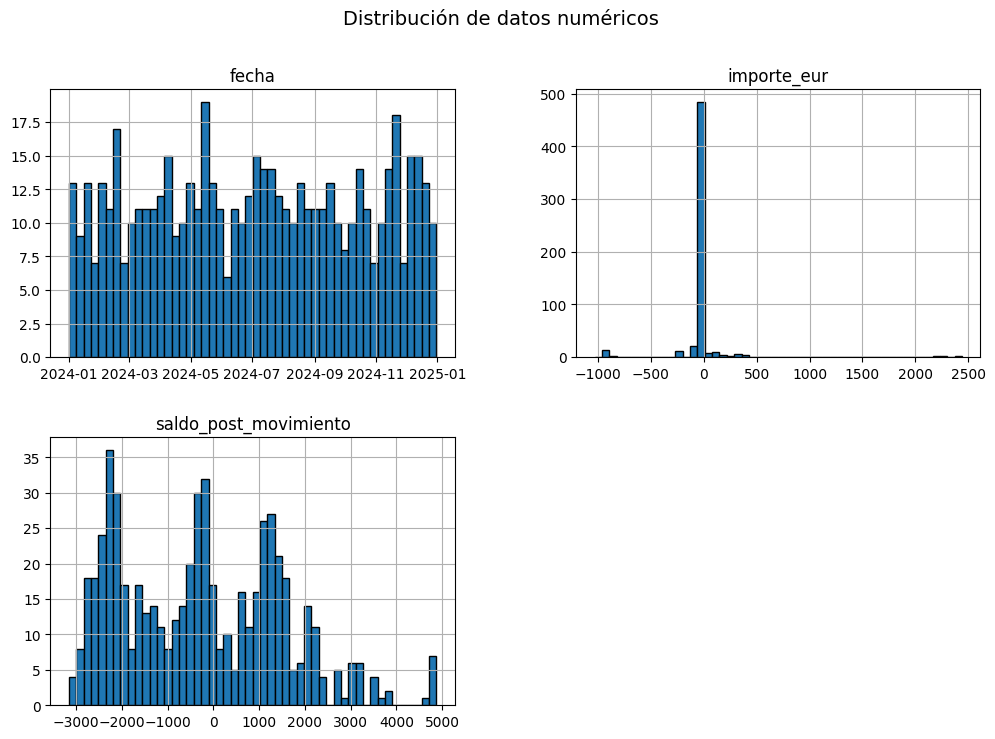

In [11]:
df.hist(figsize=(12,8), bins= 50, edgecolor = "black")
plt.suptitle("Distribución de datos numéricos", fontsize = 14)
plt.ylabel("Cantidad de movimientos")
plt.show()

En el grafico de importe_eur:
* la mayoria de los importes estan cerca del 0
* hay colas largas positivas y negativas
* existen movimientos grandes pocos frecuentes a analizar.


En el saldo_post_movimiento:
* Hay una zona negativa muy notoria
* El saldo negativo ocurre muchas veces
* Presenta alerta de riesgos

### Detección de Outliers

In [12]:
q1 = df["importe_eur"].quantile(0.25)
q3 = df["importe_eur"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers_importe = df[
    (df["importe_eur"] < lim_inf) | (df["importe_eur"] > lim_sup)
]

outliers_importe

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,NaN
7,2024-01-04,Ingreso,Bizum,76.83,4760.87,Bizum recibido,Bizum,January,Thursday,NaN
8,2024-01-05,Gasto,Alquiler,-900.00,3860.87,Cargo Alquiler,Débito,January,Friday,NaN
10,2024-01-07,Gasto,Préstamo personal,-220.00,3601.15,Cargo Préstamo personal,Débito,January,Sunday,NaN
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN
...,...,...,...,...,...,...,...,...,...,...
535,2024-12-05,Gasto,Alquiler,-900.00,-1166.66,Cargo Alquiler,Débito,December,Thursday,Saldo negativo
539,2024-12-07,Gasto,Préstamo personal,-220.00,-1510.90,Cargo Préstamo personal,Débito,December,Saturday,Saldo negativo
558,2024-12-16,Ingreso,Bizum,52.68,-2048.14,Bizum recibido,Bizum,December,Monday,Saldo negativo
573,2024-12-24,Ingreso,Ingreso extra,390.27,-2196.98,Ingreso puntual,Transferencia,December,Tuesday,Saldo negativo


In [13]:
outliers_importe.sort_values("importe_eur")

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN
8,2024-01-05,Gasto,Alquiler,-900.00,3860.87,Cargo Alquiler,Débito,January,Friday,NaN
96,2024-03-05,Gasto,Alquiler,-900.00,2080.68,Cargo Alquiler,Débito,March,Tuesday,NaN
51,2024-02-05,Gasto,Alquiler,-900.00,2053.80,Cargo Alquiler,Débito,February,Monday,NaN
192,2024-05-05,Gasto,Alquiler,-900.00,362.51,Cargo Alquiler,Débito,May,Sunday,NaN
...,...,...,...,...,...,...,...,...,...,...
477,2024-11-01,Ingreso,Salario,2280.93,-625.19,Nómina mensual,Transferencia,November,Friday,Saldo negativo
432,2024-10-01,Ingreso,Salario,2345.26,-814.34,Nómina mensual,Transferencia,October,Tuesday,Saldo negativo
0,2024-01-01,Ingreso,Salario,2374.51,4874.51,Nómina mensual,Transferencia,January,Monday,NaN
188,2024-05-01,Ingreso,Salario,2427.84,2253.35,Nómina mensual,Transferencia,May,Wednesday,NaN


In [14]:
(outliers_importe["importe_eur"]<0).sum()

np.int64(37)

In [15]:
(outliers_importe["importe_eur"]>0).sum()

np.int64(44)

Hay mas importes extraordinarios positivos que negativos, tenemos que estudiar si esos importes son de mayor impacto o no sobre el saldo. 

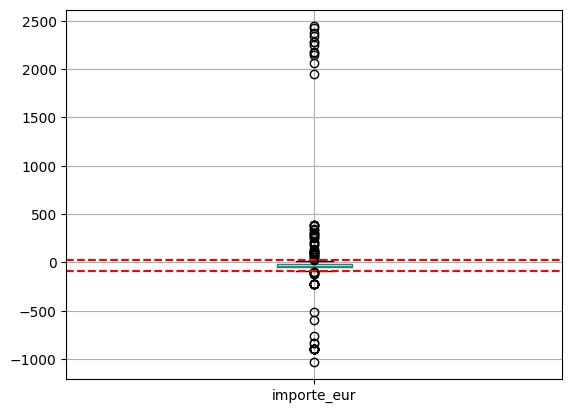

In [16]:
df.boxplot(column="importe_eur")
plt.axhline(lim_inf, color="red", linestyle="--")
plt.axhline(lim_sup, color="red", linestyle="--")
plt.show()


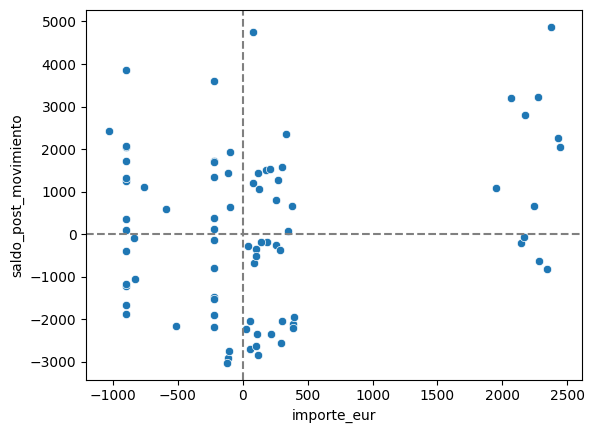

In [17]:
sns.scatterplot(
    data=outliers_importe,
    x="importe_eur",
    y="saldo_post_movimiento"
)
plt.axvline(0, color="grey", linestyle="--")
plt.axhline(0, color="grey", linestyle="--")
plt.show()


In [18]:
outliers_importe["signo"] = np.where(outliers_importe["importe_eur"]>0,"Ingreso extremo","Gasto extremo")

outliers_importe.groupby("signo")["saldo_post_movimiento"].agg(
    promedio="mean",
    mediana="median",
    minimo="min",
    maximo="max",
    cantidad="count"
).round(2)

,promedio,mediana,minimo,maximo,cantidad
signo,,,,,
Gasto extremo,93.95,116.34,-3019.71,3860.87,37
Ingreso extremo,136.67,-178.36,-2836.29,4874.51,44


Vemos que cuando el cliente a pesar de tener un gasto grande, por tener anteriormente una cantidad de saldo considerable, en promedio termina en positivo. Esto quiere decir que al momento de tener ese gasto, el cliente era conciente del dinero que disponia.
Pero a pesar de tener ingresos grandes, tambien presenta momentos donde el saldo lo tiene en negativo por lo que hay en un momento de su saldo, que no pudo saldar los gastos grandes.

In [19]:
outliers_importe["descripcion"].unique()

<StringArray>
[         'Nómina mensual',          'Bizum recibido',
          'Cargo Alquiler', 'Cargo Préstamo personal',
      'Compra excepcional',         'Ingreso puntual',
           'Bizum enviado']
Length: 7, dtype: str

In [20]:
outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,signo
15,2024-01-11,Gasto,Gasto extraordinario,-1033.92,2414.51,Compra excepcional,Tarjeta,January,Thursday,NaN,Gasto extremo
30,2024-01-20,Gasto,Gasto extraordinario,-759.67,1120.75,Compra excepcional,Tarjeta,January,Saturday,NaN,Gasto extremo
177,2024-04-25,Gasto,Gasto extraordinario,-838.60,-77.99,Compra excepcional,Tarjeta,April,Thursday,Saldo negativo,Gasto extremo
191,2024-05-03,Gasto,Gasto extraordinario,-897.18,1262.51,Compra excepcional,Tarjeta,May,Friday,NaN,Gasto extremo
294,2024-07-06,Gasto,Gasto extraordinario,-593.82,591.62,Compra excepcional,Tarjeta,July,Saturday,NaN,Gasto extremo
322,2024-07-20,Gasto,Gasto extraordinario,-829.57,-1041.46,Compra excepcional,Tarjeta,July,Saturday,Saldo negativo,Gasto extremo
403,2024-09-10,Gasto,Gasto extraordinario,-517.08,-2159.11,Compra excepcional,Tarjeta,September,Tuesday,Saldo negativo,Gasto extremo


In [21]:
outliers_importe[outliers_importe["descripcion"]== "Compra excepcional"]["importe_eur"].sum()

np.float64(-5469.839999999999)

Presenta varios cargos excepcionales. Los cuales los mas preocupantes son cuando su saldo pasa a ser negativo.

In [48]:
gastos_fijos = pd.concat([outliers_importe[outliers_importe["descripcion"] == "Cargo Alquiler"],outliers_importe[outliers_importe["descripcion"] == "Cargo Préstamo personal"]])
gastos_fijos.head(5)

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta,signo
8,2024-01-05,Gasto,Alquiler,-900.0,3860.87,Cargo Alquiler,Débito,January,Friday,NaN,Gasto extremo
51,2024-02-05,Gasto,Alquiler,-900.0,2053.80,Cargo Alquiler,Débito,February,Monday,NaN,Gasto extremo
96,2024-03-05,Gasto,Alquiler,-900.0,2080.68,Cargo Alquiler,Débito,March,Tuesday,NaN,Gasto extremo
145,2024-04-05,Gasto,Alquiler,-900.0,1725.59,Cargo Alquiler,Débito,April,Friday,NaN,Gasto extremo
192,2024-05-05,Gasto,Alquiler,-900.0,362.51,Cargo Alquiler,Débito,May,Sunday,NaN,Gasto extremo


In [50]:
f"El cliente presenta gastos fijos durante el año de: {gastos_fijos['importe_eur'].sum()}"

'El cliente presenta gastos fijos durante el año de: -13440.0'

### Análisis categoria

In [25]:
categoria_gasto = df[df["importe_eur"]<0]["categoria"].value_counts().reset_index()

In [26]:
categoria_gasto

,categoria,count
0,Alimentación,141
1,Transporte,79
2,Restaurantes,54
3,Ocio,38
4,Otros,36
5,Ropa,28
6,Salud,28
7,Bizum,16
8,Educación,13
9,Alquiler,12


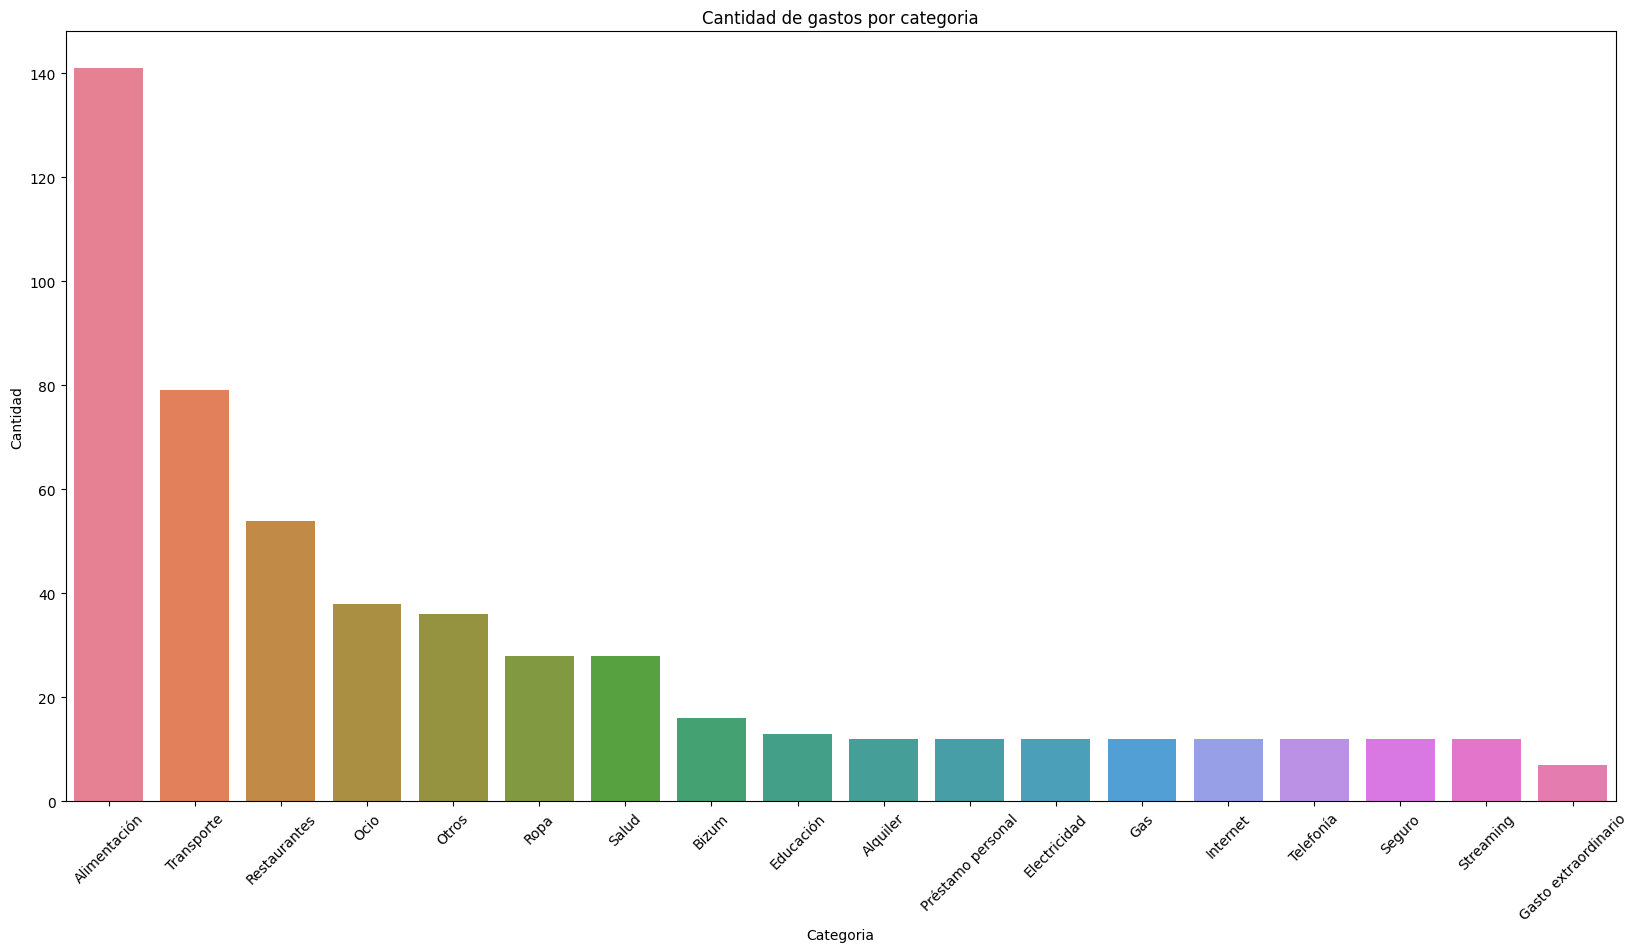

In [27]:
plt.figure(figsize = (20,10))
sns.barplot(data=categoria_gasto,x="categoria", y="count", hue="categoria")
plt.title("Cantidad de gastos por categoria")
plt.xlabel("Categoria")
plt.ylabel("Cantidad")
plt.xticks(rotation= 45)
plt.show()

Podemos chequear que en lo que mas se gasta es en Alimentacion, esto esta hecho por cantidad de veces que se gasto en cierta categoria, no en dinero. 

In [62]:
gasto_por_categoria = df.groupby("categoria")["importe_eur"].sum().sort_values().abs().reset_index()
top5_gasto_personal = gasto_por_categoria.head(5)

TOP 5 de gastos durante el año.

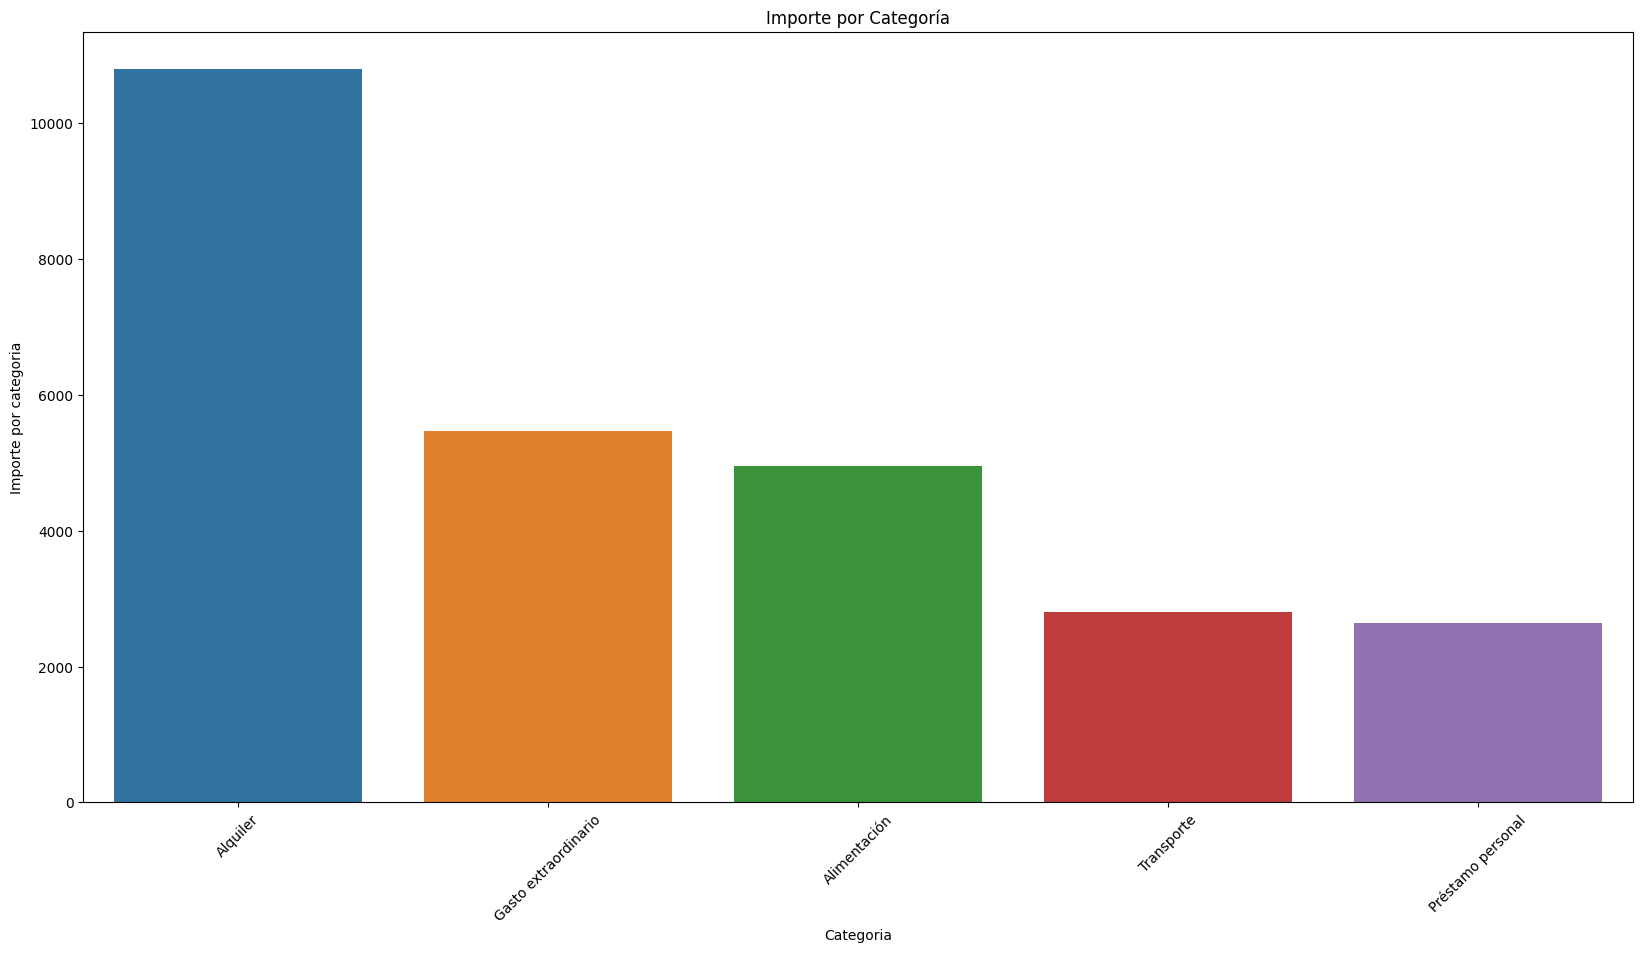

In [66]:
plt.figure(figsize=(20,10))
sns.barplot(data=top5_gasto_personal, x="categoria", y="importe_eur", hue="categoria")
plt.title("Importe por Categoría")
plt.xlabel("Categoria")
plt.ylabel("Importe por categoria")
plt.xticks(rotation=45)
plt.show()

### Análisis por mes

In [30]:
gastos_por_mes = df[df["importe_eur"]<0]
gastos = gastos_por_mes.groupby("mes")["importe_eur"].sum().abs()


ingresos_por_mes = df[df["importe_eur"]>0]
ingresos = ingresos_por_mes.groupby("mes")["importe_eur"].sum()

resumen_mensual = pd.DataFrame({
    "gastos": gastos,
    "ingresos": ingresos
})

resumen_mensual = (
    resumen_mensual.reset_index().melt(
        id_vars="mes",
        value_vars=["gastos","ingresos"],
        var_name="tipo",
        value_name="monto"
    )
)

resumen_mensual

,mes,tipo,monto
0,April,gastos,3470.69
1,August,gastos,3030.26
2,December,gastos,2899.48
3,February,gastos,2673.04
4,January,gastos,4289.92
5,July,gastos,4355.99
6,June,gastos,2112.87
7,March,gastos,2936.36
8,May,gastos,3789.75
9,November,gastos,2649.45


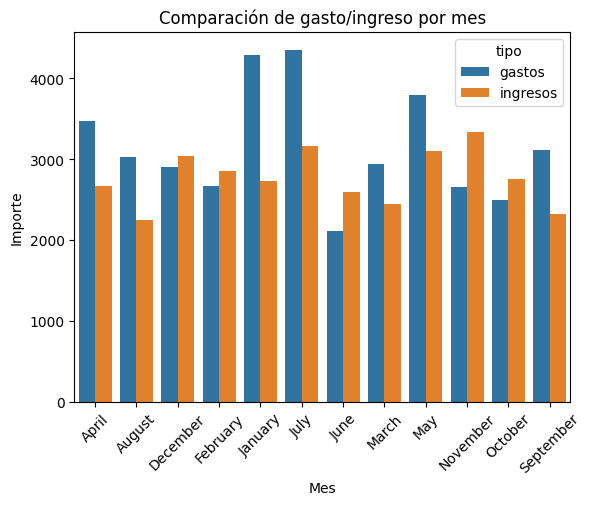

In [31]:
plt.Figure(figsize=(20,10))
sns.barplot(data=resumen_mensual, x="mes", y="monto", hue="tipo")
plt.title("Comparación de gasto/ingreso por mes")
plt.xlabel("Mes")
plt.ylabel("Importe")
plt.xticks(rotation= 45)
plt.show()

Vemos una clara tendencia de gastar más de lo que ingresa, por lo que el ahorro se dificulta.

In [32]:
mes_post = []

for index,valor in df["mes"].items():
    mes_post.append(df[df["mes"]== valor].iloc[-1])
    
post = pd.DataFrame(mes_post)
post_sin_duplicados = post.drop_duplicates()
post_sin_duplicados

,fecha,tipo_movimiento,categoria,importe_eur,saldo_post_movimiento,descripcion,canal,mes,dia,alerta
43,2024-01-31,Gasto,Ropa,-41.39,936.50,Pago con tarjeta,Tarjeta,January,Wednesday,NaN
90,2024-02-29,Gasto,Ocio,-20.39,1122.51,Pago con tarjeta,Tarjeta,February,Thursday,NaN
138,2024-03-31,Gasto,Bizum,-97.94,632.83,Bizum enviado,Bizum,March,Sunday,NaN
187,2024-04-30,Ingreso,Ingreso extra,186.72,-174.49,Ingreso puntual,Transferencia,April,Tuesday,Saldo negativo
243,2024-05-31,Gasto,Salud,-9.11,-866.75,Pago con tarjeta,Tarjeta,May,Friday,Saldo negativo
280,2024-06-30,Ingreso,Ingreso extra,288.53,-381.03,Ingreso puntual,Transferencia,June,Sunday,Saldo negativo
339,2024-07-30,Gasto,Transporte,-26.13,-1579.89,Pago con tarjeta,Tarjeta,July,Tuesday,Saldo negativo
388,2024-08-31,Gasto,Transporte,-56.50,-2361.59,Pago con tarjeta,Tarjeta,August,Saturday,Saldo negativo
431,2024-09-29,Gasto,Transporte,-34.43,-3159.60,Pago con tarjeta,Tarjeta,September,Sunday,Saldo negativo
476,2024-10-30,Gasto,Transporte,-12.90,-2906.13,Pago con tarjeta,Tarjeta,October,Wednesday,Saldo negativo


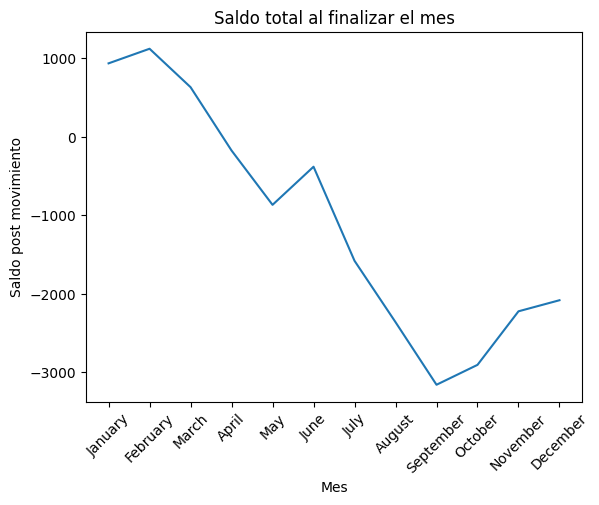

In [33]:
plt.Figure(figsize=(20,10))
sns.lineplot(data= post_sin_duplicados, x= "mes", y= "saldo_post_movimiento")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Saldo total al finalizar el mes")
plt.xticks(rotation = 45)
plt.show()

Vemos una clara descendencia del salario al finalizar cada mes. Hay un ligero repunte en el mes de junio que luego vuelve a caer.
A partir de Septiembre, comienza un nuevo crecimiento del saldo.
Hay que analizar los gastos por categorias desde junio a septiembre para saber por que baja mucho el saldo y no logra repuntar, que tipos de gastos se hizo? 
Luego en septiembre se vio un repunte hacia arriba? por que se debe esto? que gasto no se esta haciendo? puede ser la finalizacion de un prestamo? o ha ingresado mas dinero de lo habitual?

In [34]:
df.sort_values("fecha")
meses_ordenados = ["January","February","March","April","May","June","July","August","September","October","November","December"]

df["mes"] = pd.Categorical(df["mes"],categories=meses_ordenados, ordered=True)

df_mes_ingreso_y_gasto = df.groupby("mes").agg(
    ingresos=("importe_eur", lambda x: x[x>0].sum()),
    gastos=("importe_eur", lambda x: x[x<0].sum()),
    saldo_final=("saldo_post_movimiento", "last")
)


df_mes_ingreso_y_gasto



,ingresos,gastos,saldo_final
mes,,,
January,2726.40,-4289.92,936.50
February,2859.07,-2673.04,1122.51
March,2446.67,-2936.36,632.83
April,2663.34,-3470.69,-174.49
May,3097.48,-3789.75,-866.75
June,2598.59,-2112.87,-381.03
July,3157.15,-4355.99,-1579.89
August,2248.55,-3030.26,-2361.59
September,2318.62,-3116.63,-3159.60


In [35]:
df_diferencia = df_mes_ingreso_y_gasto["ingresos"] + df_mes_ingreso_y_gasto["gastos"]
df_diferencia = df_diferencia.reset_index(name="Diferencia ingreso - gasto")
df_diferencia

,mes,Diferencia ingreso - gasto
0,January,-1563.52
1,February,186.03
2,March,-489.69
3,April,-807.35
4,May,-692.27
5,June,485.72
6,July,-1198.84
7,August,-781.71
8,September,-798.01
9,October,253.49


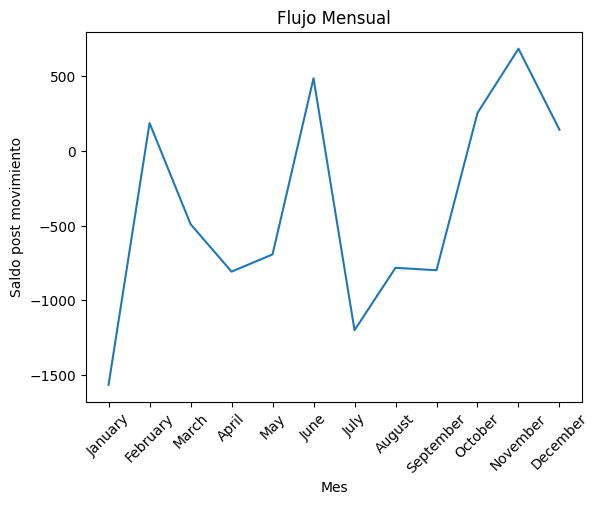

In [36]:
plt.Figure(figsize=(20,10))
sns.lineplot(data= df_diferencia, x= "mes", y= "Diferencia ingreso - gasto")
plt.xlabel("Mes")
plt.ylabel("Saldo post movimiento")
plt.title("Flujo Mensual")
plt.xticks(rotation = 45)
plt.show()

Vemos que el cliente tiene varios repuntes de su saldo, donde enero y julio son los meses que peor caida presente. Hay que averiguar que categoria es la culpable en estos 2 meses para saber donde poder interferir para mejorar su ahorro

1. ¿Qué porcentaje de mis ingresos se va a cada categoría de gasto y cómo ha evolucionado mes a mes?

In [37]:
ingresos = pd.DataFrame(ingresos)
ingresos.reset_index()

,mes,importe_eur
0,April,2663.34
1,August,2248.55
2,December,3040.60
3,February,2859.07
4,January,2726.40
5,July,3157.15
6,June,2598.59
7,March,2446.67
8,May,3097.48
9,November,3332.01


In [38]:
gastos_cat_por_mes = gastos_por_mes.groupby(["categoria","mes"])["importe_eur"].sum().reset_index()
gastos_cat_por_mes = pd.DataFrame(gastos_cat_por_mes)
gastos_cat_por_mes

,categoria,mes,importe_eur
0,Alimentación,April,-341.90
1,Alimentación,August,-632.70
2,Alimentación,December,-539.57
3,Alimentación,February,-333.02
4,Alimentación,January,-355.83
...,...,...,...
193,Transporte,March,-267.26
194,Transporte,May,-278.07
195,Transporte,November,-239.09
196,Transporte,October,-134.88


In [39]:
ingr_gas_por_mes = pd.merge(ingresos, gastos_cat_por_mes,how="inner",on="mes")
ingr_gas_por_mes

,mes,importe_eur_x,categoria,importe_eur_y
0,April,2663.34,Alimentación,-341.90
1,April,2663.34,Alquiler,-900.00
2,April,2663.34,Bizum,-40.46
3,April,2663.34,Educación,-24.44
4,April,2663.34,Electricidad,-70.00
...,...,...,...,...
193,September,2318.62,Ropa,-112.70
194,September,2318.62,Seguro,-45.00
195,September,2318.62,Streaming,-25.00
196,September,2318.62,Telefonía,-35.00


In [40]:
ingr_gas_por_mes["porcentaje"] = round((ingr_gas_por_mes["importe_eur_y"] / ingr_gas_por_mes["importe_eur_x"])*100, 2).abs()

ingr_gas_por_mes

,mes,importe_eur_x,categoria,importe_eur_y,porcentaje
0,April,2663.34,Alimentación,-341.90,12.84
1,April,2663.34,Alquiler,-900.00,33.79
2,April,2663.34,Bizum,-40.46,1.52
3,April,2663.34,Educación,-24.44,0.92
4,April,2663.34,Electricidad,-70.00,2.63
...,...,...,...,...,...
193,September,2318.62,Ropa,-112.70,4.86
194,September,2318.62,Seguro,-45.00,1.94
195,September,2318.62,Streaming,-25.00,1.08
196,September,2318.62,Telefonía,-35.00,1.51


In [41]:
ingr_gas_por_mes["mes"] = pd.Categorical(ingr_gas_por_mes["mes"],categories=meses_ordenados, ordered=True)

top_categoria_porcentaje = ingr_gas_por_mes.groupby("categoria")["porcentaje"].mean().sort_values(ascending=False).head(5).index



df_plot = ingr_gas_por_mes[ingr_gas_por_mes["categoria"].isin(top_categoria_porcentaje)]

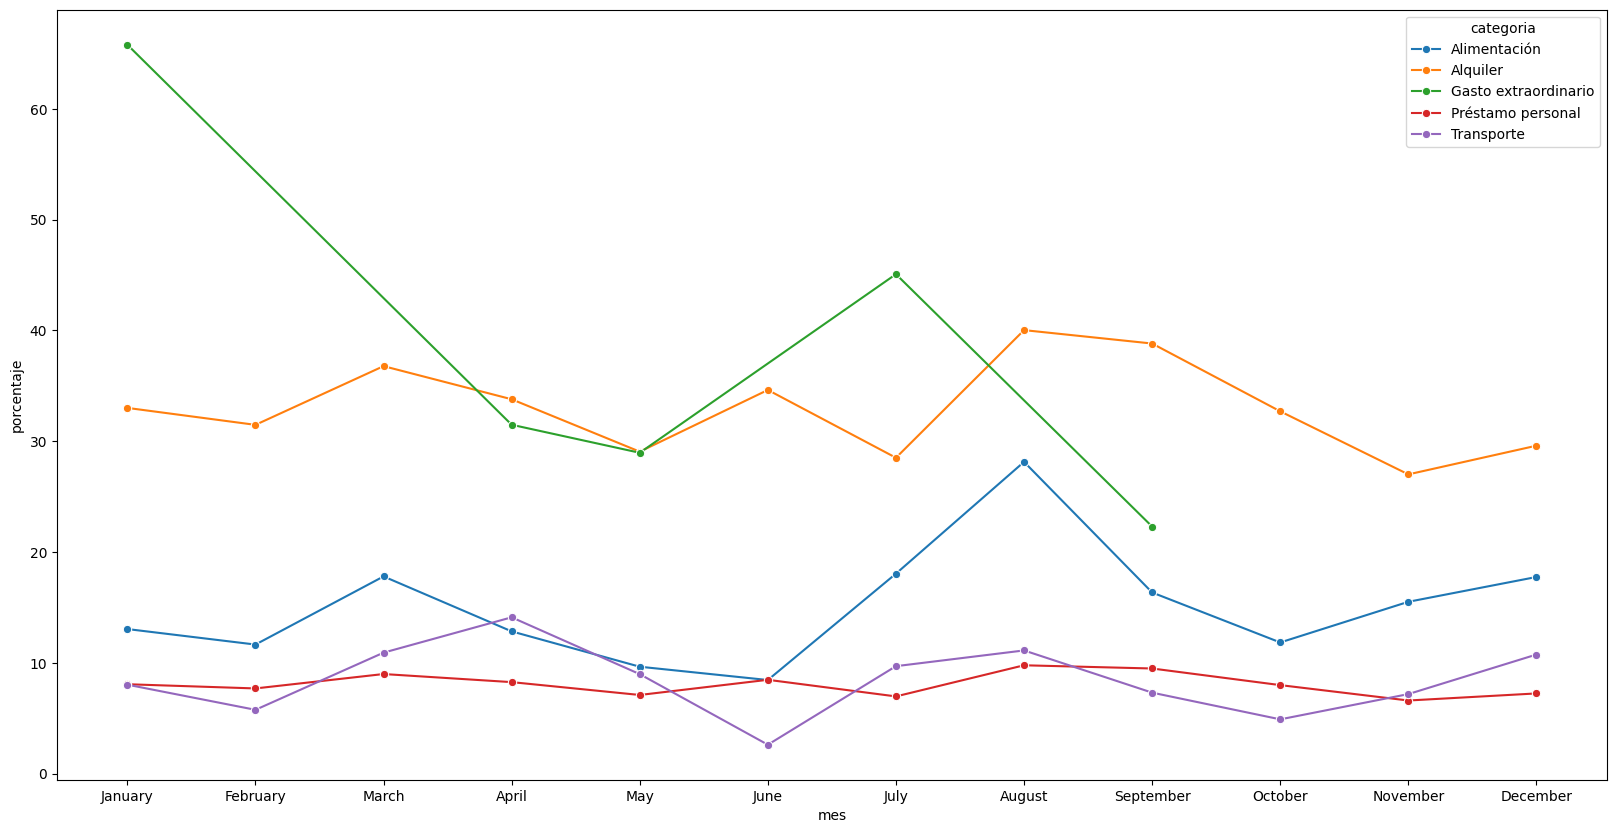

In [42]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df_plot, x="mes", y="porcentaje",hue="categoria", marker="o")
plt.show()

El gráfico muestra que los picos en el porcentaje del ingreso destinado a gastos se producen principalmente en los meses en los que aparecen gastos extraordinarios.
Estos eventos generan el mayor impacto negativo sobre el saldo mensual, debido a su carácter puntual y no recurrente.

En contraste, el alquiler representa de forma consistente el mayor porcentaje del gasto mensual; sin embargo, su impacto es estructural y previsible, ya que se trata de un gasto fijo.

La alimentación también corresponde a un gasto fijo, aunque se observa un incremento significativo en el mes de agosto. Este aumento podría estar asociado a factores estacionales, como vacaciones, mayor consumo fuera del hogar o gastos extraordinarios vinculados al período.

Por último, el préstamo personal y el transporte presentan una evolución relativamente lineal, lo que indica que su porcentaje sobre el ingreso se mantiene estable a lo largo del tiempo y no genera desequilibrios significativos en el presupuesto mensual.

2. ¿Hay meses con el mismo nivel de ingresos pero distintos niveles de saldo final? ¿A qué categorías se debe la diferencia?

In [47]:
media_ingresos = round(ingresos["importe_eur"].mean(),2)
f"La media de los ingresos ronda los {media_ingresos}"

'La media de los ingresos ronda los 2770.06'

De enero a septiembre vemos que presenta gastos extraordinarios, los cuales modifican sustenciamente el saldo a fin de mes. Podemos comprobar que a partir de que el cliente no tiene mas esos gastos, el saldo final sube levemente. Hay que tener en cuenta que los gastos arastraron una baja sustencial mes a mes por lo que es ese el motivo del crecimiento de forma leve. 

3. ¿Hay meses con ‘picos’ de gasto que ponen en riesgo mantener un saldo mínimo de seguridad?

de Enero a Septiembre son los meses que perjudicaron el saldo del cliente.

### Pregunta de negocio

* ¿Cómo puedo optimizar mi estructura de gastos para aumentar mi ahorro mensual sin reducir en exceso mi calidad de vida?

Podemos afirmar que el cliente tuvo una caida notoria de su saldo debido a gastos extraordinarios que afectaron el ahorro mensual. Eran gastos que se generaban en un momento donde el cliente no disponia de ese dinero, por lo que por eso llega a negativo, presentando una preocupante situacion. 
La manera de optimizar la estructura de gastos seria, no gastar mas de lo que tengo.